Existing calibration (fixed): theta=0.5000, alpha=0.0100, beta=1.5000
Calibrated OU parameters (one‑regime): θ = 0.2575, μ_Y = 6.8687, σ_Y = 1.6339
Optimal N_c estimated from 2010–2013 monthly data = -8192.0 contracts per month
2014 Unhedged MAPE: 8.40%
2014 Hedged MAPE:   9.60%


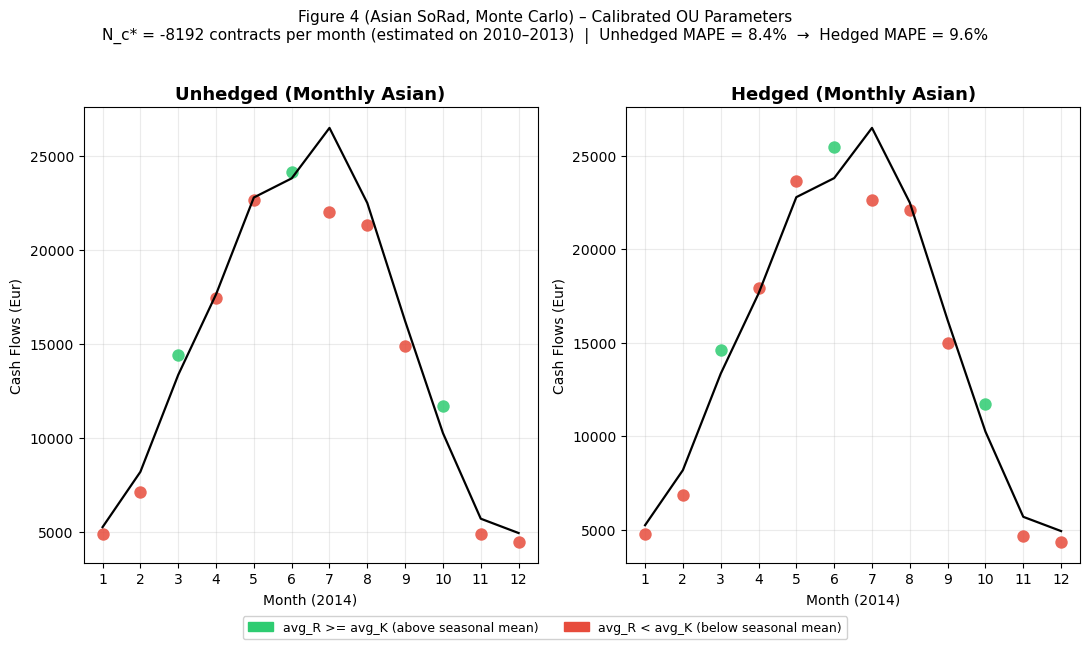

Saved Figure4_asian_sorad_mc_calibrated.png


In [9]:
# Adapted notebook: figure4-asian-sorad-montecarlo-calibrated.ipynb

# %% [markdown]
# # Figure 4 (Asian SoRad) – Monte Carlo Pricing with Calibrated OU Parameters

# %% [markdown]
# ## 0. Imports and Data

# %%
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from statsmodels.tsa.ar_model import AutoReg

from solarrpy.calibration import calibrate_window
from solarrpy.sorad import daily_strike
from solarrpy.buyer import tick

# %% [markdown]
# ## 1. Load and calibrate (2005–2013) – existing for daily strikes

# %%
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()

LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

df_train = df[df['Year'] <= 2013].copy()
cal = calibrate_window(
    df_train,
    target_col='GHI', clearsky_col='clearsky', date_col='date',
    coords={'lat': LATITUDE}, train_end_year=2013,
)
print(f'Existing calibration (fixed): theta={cal.theta:.4f}, alpha={cal.alpha:.4f}, beta={cal.beta:.4f}')

# %% [markdown]
# ## 2. New calibration: one‑regime OU parameters from training data

# %%
a, b = 0.1, 0.5   # R = a * exp(b * Y)   →   Y = log(R/a)/b

def transform_to_Y(R):
    return np.log(R / a) / b

Y_train = transform_to_Y(df_train['GHI'].values)

# Estimate OU parameters via MLE on the discretized AR(1) process
# Y_t = c + φ Y_{t-1} + ε_t, ε_t ~ N(0, σ_ε^2)
# Replace the estimation cell with this corrected version

def estimate_ou_mle(Y):
    """
    Estimate one‑regime OU parameters from Y using an AR(1) model.
    Returns (theta, mu, sigma) where:
        theta = -ln(phi)  (mean-reversion speed)
        mu = c / (1 - phi)   (long-term mean)
        sigma = std(residuals) / sqrt(1 - phi^2)   (volatility)
    """
    # Fit AR(1) with intercept
    model = AutoReg(Y, lags=1, old_names=False).fit()
    phi = model.params[1]
    c = model.params[0]
    # Residual standard deviation
    sigma_eps = np.std(model.resid, ddof=1)   # ddof=1 for unbiased estimate
    # Ensure phi is positive for log; if negative, use absolute value (rare for solar)
    if phi <= 0:
        # fallback: use a small positive value
        phi = 0.01
    theta = -np.log(phi)
    mu = c / (1 - phi) if abs(phi) < 0.999 else c / (1 - 0.999)
    sigma = sigma_eps / np.sqrt(1 - phi**2)
    return theta, mu, sigma

theta_est, mu_Y_est, sigma_Y_est = estimate_ou_mle(Y_train)

print(f'Calibrated OU parameters (one‑regime): θ = {theta_est:.4f}, μ_Y = {mu_Y_est:.4f}, σ_Y = {sigma_Y_est:.4f}')

# %% [markdown]
# ## 3. Monte Carlo pricing of the Asian put (fixed seed across months)

# %%
def simulate_OU_paths(Y0, theta, mu, sigma, dt, n_steps, n_paths, seed):
    np.random.seed(seed)
    Y = np.zeros((n_paths, n_steps + 1))
    Y[:, 0] = Y0
    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dW = np.random.normal(0, sqrt_dt, n_paths)
        dY = -theta * (Y[:, i] - mu) * dt + sigma * dW
        Y[:, i+1] = Y[:, i] + dY
    return Y

def asian_put_price_mc(strike_R, t0, start_date, end_date, theta, mu_Y, sigma_Y, a, b,
                       tick=0.10, n_paths=200000, n_steps_per_day=1, seed=42):
    """
    Price Asian put using Monte Carlo. Same seed across months ensures consistency.
    """
    t0_date = pd.to_datetime(t0)
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    days = (end - start).days + 1
    dt = 1.0 / n_steps_per_day
    
    Y0 = transform_to_Y(R_t0)
    sim_steps = int((end - t0_date).days) * n_steps_per_day
    Y_sim = simulate_OU_paths(Y0, theta, mu_Y, sigma_Y, dt, sim_steps, n_paths, seed)
    
    offset_start = int((start - t0_date).days) * n_steps_per_day
    offset_end = int((end - t0_date).days) * n_steps_per_day + 1
    Y_daily = Y_sim[:, offset_start:offset_end:n_steps_per_day]
    
    R_daily = a * np.exp(b * Y_daily)
    R_avg = R_daily.mean(axis=1)
    payoff = tick * np.maximum(strike_R - R_avg, 0)
    return np.mean(payoff)

# %% [markdown]
# ## 4. Monthly aggregation for training (2010–2013) and test (2014)

# %%
def compute_monthly_data(df, cal, t0_date, R_t0, theta, mu_Y, sigma_Y, a, b):
    """
    Compute monthly aggregates and Asian put premiums for a given year's dataframe.
    The df is expected to contain data for a single calendar year.
    """
    df = df.reset_index(drop=True)
    K_arr = np.array([daily_strike(row['date'], cal) for _, row in df.iterrows()])
    monthly = []
    for (year, month), group in df.groupby([df['date'].dt.year, df['date'].dt.month]):
        idx = group.index
        avg_R = group['GHI'].mean()
        avg_K = K_arr[idx].mean()
        total_R = group['GHI'].sum()
        total_K = K_arr[idx].sum()
        start_date = group['date'].iloc[0]
        end_date = group['date'].iloc[-1]
        
        V0 = asian_put_price_mc(avg_K, t0_date, start_date, end_date,
                                theta, mu_Y, sigma_Y, a, b, tick,
                                n_paths=200000, seed=42)
        monthly.append({
            'year': year,
            'month': month,
            'avg_R': avg_R,
            'avg_K': avg_K,
            'total_R': total_R,
            'total_K': total_K,
            'V0': V0,
        })
    return pd.DataFrame(monthly)

def get_conditioning_year(df, year):
    year_data = df[df['Year'] == year].sort_values('date')
    if len(year_data) == 0:
        raise ValueError(f"No data for year {year}")
    last_row = year_data.iloc[-1]
    return last_row['date'], float(last_row['GHI'])

# Build training data 2010–2013 using calibrated OU parameters
train_months = []
for year in range(2010, 2014):
    df_year = df[df['Year'] == year].copy()
    t0_date, R_t0 = get_conditioning_year(df, year-1)
    monthly = compute_monthly_data(df_year, cal, t0_date, R_t0,
                                   theta_est, mu_Y_est, sigma_Y_est, a, b)
    train_months.append(monthly)
train_df = pd.concat(train_months, ignore_index=True)

# Build test data 2014
t0_date_2014, R_t0_2014 = get_conditioning_year(df, 2013)
df_2014 = df[df['Year'] == 2014].copy()
test_df = compute_monthly_data(df_2014, cal, t0_date_2014, R_t0_2014,
                               theta_est, mu_Y_est, sigma_Y_est, a, b)

# %% [markdown]
# ## 5. Estimate optimal hedge ratio on training data (2010–2013)

# %%
Ef = 0.15
Np = 10000
E_bar = 0.08
tick_val = 0.10

def optimal_Nc_from_df(df):
    cf_u = Ef * Np * E_bar * df['total_R'].values
    cf_b = Ef * Np * E_bar * df['total_K'].values
    payoff = tick_val * np.maximum(df['avg_K'] - df['avg_R'], 0)
    premium = df['V0'].values
    X = cf_u - cf_b
    P = payoff - premium
    cov = np.cov(X, P, ddof=0)[0,1]
    var = np.var(P, ddof=0)
    return cov / var if var > 0 else 0.0

N_c = optimal_Nc_from_df(train_df)
print(f'Optimal N_c estimated from 2010–2013 monthly data = {N_c:.1f} contracts per month')

# Apply to test year 2014
cf_u_test = Ef * Np * E_bar * test_df['total_R'].values
cf_b_test = Ef * Np * E_bar * test_df['total_K'].values
payoff_test = tick_val * np.maximum(test_df['avg_K'] - test_df['avg_R'], 0)
premium_test = test_df['V0'].values

cf_h_test = cf_u_test + N_c * (payoff_test - premium_test)

def mape(actual, benchmark):
    return np.mean(np.abs((actual - benchmark) / benchmark)) * 100

print(f'2014 Unhedged MAPE: {mape(cf_u_test, cf_b_test):.2f}%')
print(f'2014 Hedged MAPE:   {mape(cf_h_test, cf_b_test):.2f}%')

# Colour: green if avg_R >= avg_K
above = test_df['avg_R'] >= test_df['avg_K']

# %% [markdown]
# ## 6. Figure: Unhedged vs Hedged monthly cash flows (2014)

# %%
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=False)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='avg_R >= avg_K (above seasonal mean)'),
    mpatches.Patch(color='#e74c3c', label='avg_R < avg_K (below seasonal mean)'),
]

months = np.arange(1, 13)
for ax, cf_vals, title in [
    (axes[0], cf_u_test, 'Unhedged (Monthly Asian)'),
    (axes[1], cf_h_test, 'Hedged (Monthly Asian)'),
]:
    ax.scatter(months[above], cf_vals[above], s=80, color='#2ecc71', alpha=0.85, zorder=3, linewidths=0)
    ax.scatter(months[~above], cf_vals[~above], s=80, color='#e74c3c', alpha=0.85, zorder=3, linewidths=0)
    ax.plot(months, cf_b_test, color='black', lw=1.6, zorder=4, label='Seasonal benchmark')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Month (2014)', fontsize=10)
    ax.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax.set_xlim(0.5, 12.5)
    ax.set_xticks(months)
    ax.grid(True, alpha=0.25)

fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Figure 4 (Asian SoRad, Monte Carlo) – Calibrated OU Parameters\n'
    f'N_c* = {N_c:.0f} contracts per month (estimated on 2010–2013)  |  '
    f'Unhedged MAPE = {mape(cf_u_test, cf_b_test):.1f}%  →  Hedged MAPE = {mape(cf_h_test, cf_b_test):.1f}%',
    fontsize=11, y=1.02
)
fig.tight_layout()
plt.savefig('../results/Figure4_asian_sorad_mc_calibrated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure4_asian_sorad_mc_calibrated.png')

In [5]:
with open('../data/CAMS_data/CAMS_data_Bologna.csv', 'r') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 5:
            break

"date","n","Year","Month","Day","GHI","clearsky","H0"
2005-01-01,1,2005,1,1,2.1190925,2.1217434,3.09241345139894
2005-01-02,2,2005,1,2,1.9894553,2.0342498,3.106099376952
2005-01-03,3,2005,1,3,1.9163198,1.9337488,3.12111712647089
2005-01-04,4,2005,1,4,2.0465978,2.12376,3.13746546852239
2005-01-05,5,2005,1,5,1.9759948,2.0978896,3.15514290005769


Optimal N_c estimated from 2010–2013 monthly data = 0.0 contracts per month
2014 Unhedged MAPE: 8.40%
2014 Hedged MAPE:   8.40%


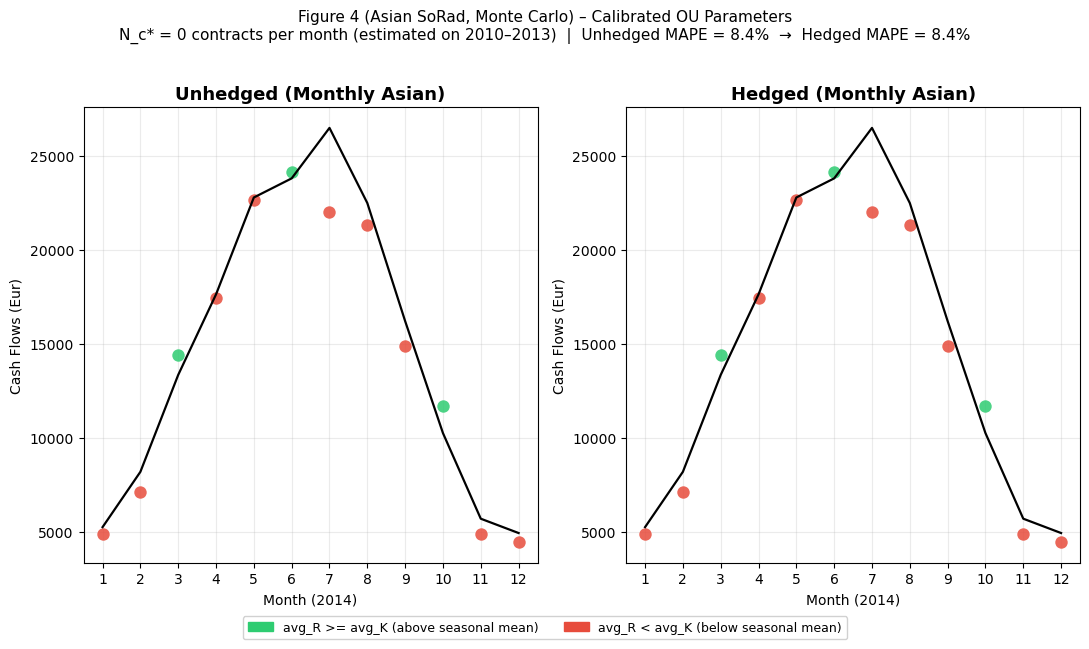

Saved Figure4_asian_sorad_mc_calibrated.png


In [10]:
def optimal_Nc_from_df(df):
    cf_u = Ef * Np * E_bar * df['total_R'].values
    cf_b = Ef * Np * E_bar * df['total_K'].values
    payoff = tick_val * np.maximum(df['avg_K'] - df['avg_R'], 0)
    premium = df['V0'].values
    X = cf_u - cf_b
    P = payoff - premium
    cov = np.cov(X, P, ddof=0)[0,1]
    var = np.var(P, ddof=0)
    return cov / var if var > 0 else 0.0

N_c_raw = optimal_Nc_from_df(train_df)
N_c = max(0, N_c_raw)
print(f'Optimal N_c estimated from 2010–2013 monthly data = {N_c:.1f} contracts per month')

# Apply to test year 2014
cf_u_test = Ef * Np * E_bar * test_df['total_R'].values
cf_b_test = Ef * Np * E_bar * test_df['total_K'].values
payoff_test = tick_val * np.maximum(test_df['avg_K'] - test_df['avg_R'], 0)
premium_test = test_df['V0'].values

cf_h_test = cf_u_test + N_c * (payoff_test - premium_test)

def mape(actual, benchmark):
    return np.mean(np.abs((actual - benchmark) / benchmark)) * 100

print(f'2014 Unhedged MAPE: {mape(cf_u_test, cf_b_test):.2f}%')
print(f'2014 Hedged MAPE:   {mape(cf_h_test, cf_b_test):.2f}%')

# Colour: green if avg_R >= avg_K
above = test_df['avg_R'] >= test_df['avg_K']

# %% [markdown]
# ## 6. Figure: Unhedged vs Hedged monthly cash flows (2014)

# %%
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=False)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='avg_R >= avg_K (above seasonal mean)'),
    mpatches.Patch(color='#e74c3c', label='avg_R < avg_K (below seasonal mean)'),
]

months = np.arange(1, 13)
for ax, cf_vals, title in [
    (axes[0], cf_u_test, 'Unhedged (Monthly Asian)'),
    (axes[1], cf_h_test, 'Hedged (Monthly Asian)'),
]:
    ax.scatter(months[above], cf_vals[above], s=80, color='#2ecc71', alpha=0.85, zorder=3, linewidths=0)
    ax.scatter(months[~above], cf_vals[~above], s=80, color='#e74c3c', alpha=0.85, zorder=3, linewidths=0)
    ax.plot(months, cf_b_test, color='black', lw=1.6, zorder=4, label='Seasonal benchmark')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Month (2014)', fontsize=10)
    ax.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax.set_xlim(0.5, 12.5)
    ax.set_xticks(months)
    ax.grid(True, alpha=0.25)

fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Figure 4 (Asian SoRad, Monte Carlo) – Calibrated OU Parameters\n'
    f'N_c* = {N_c:.0f} contracts per month (estimated on 2010–2013)  |  '
    f'Unhedged MAPE = {mape(cf_u_test, cf_b_test):.1f}%  →  Hedged MAPE = {mape(cf_h_test, cf_b_test):.1f}%',
    fontsize=11, y=1.02
)
fig.tight_layout()
plt.savefig('../results/Figure4_asian_sorad_mc_calibrated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure4_asian_sorad_mc_calibrated.png')

Existing calibration (fixed): theta=0.5000, alpha=0.0100, beta=1.5000
Calibrated OU parameters (one‑regime): θ = 0.2575, μ_Y = 6.8687, σ_Y = 1.6339
Training weeks: 212, Test weeks: 53
Raw N_c = -3098.22, using N_c = 0 contracts per week
2014 Unhedged MAPE: 17.75%
2014 Hedged MAPE:   17.75%


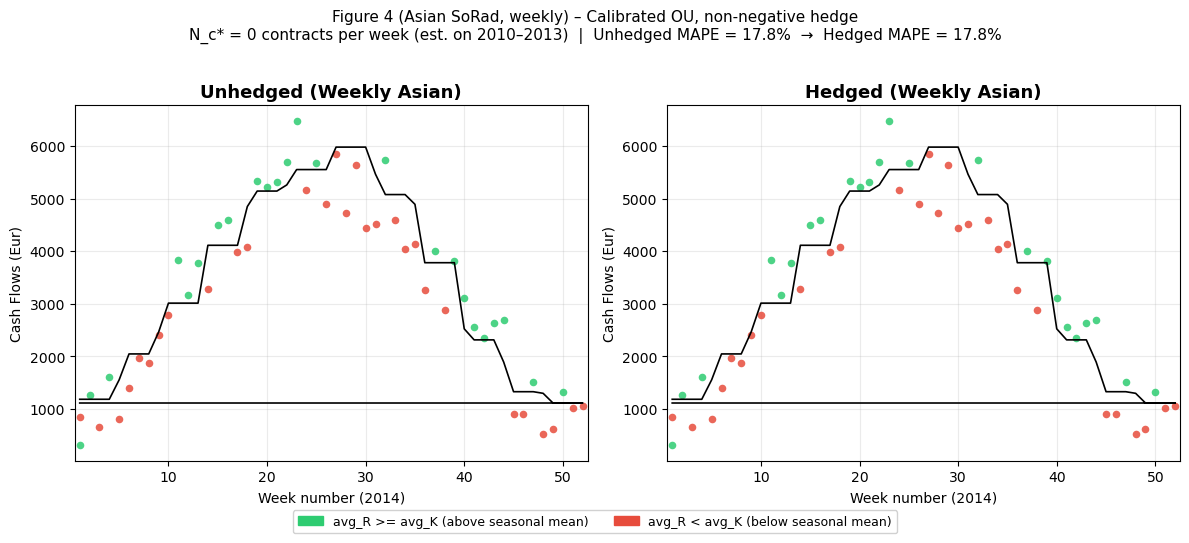

Saved Figure4_asian_sorad_weekly.png


In [ ]:

# ## 0. Imports and Data

# %%
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from statsmodels.tsa.ar_mod# Adapted notebook: figure4-asian-sorad-montecarlo-weekly.ipynb

# %% [markdown]
# # Figure 4 (Asian SoRad) – Weekly Settlement, Monte Carlo, Calibrated OU

# %% [markdown]el import AutoReg

from solarrpy.calibration import calibrate_window
from solarrpy.sorad import daily_strike
from solarrpy.buyer import tick

# %% [markdown]
# ## 1. Load and calibrate (2005–2013) – existing for daily strikes

# %%
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()

LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

df_train = df[df['Year'] <= 2013].copy()
cal = calibrate_window(
    df_train,
    target_col='GHI', clearsky_col='clearsky', date_col='date',
    coords={'lat': LATITUDE}, train_end_year=2013,
)
print(f'Existing calibration (fixed): theta={cal.theta:.4f}, alpha={cal.alpha:.4f}, beta={cal.beta:.4f}')

# %% [markdown]
# ## 2. Calibrated one‑regime OU parameters from training data

# %%
a, b = 0.1, 0.5   # R = a * exp(b * Y)   →   Y = log(R/a)/b

def transform_to_Y(R):
    return np.log(R / a) / b

Y_train = transform_to_Y(df_train['GHI'].values)

def estimate_ou_mle(Y):
    model = AutoReg(Y, lags=1, old_names=False).fit()
    phi = model.params[1]
    c = model.params[0]
    sigma_eps = np.std(model.resid, ddof=1)
    if phi <= 0:
        phi = 0.01
    theta = -np.log(phi)
    mu = c / (1 - phi) if abs(phi) < 0.999 else c / (1 - 0.999)
    sigma = sigma_eps / np.sqrt(1 - phi**2)
    return theta, mu, sigma

theta_est, mu_Y_est, sigma_Y_est = estimate_ou_mle(Y_train)

print(f'Calibrated OU parameters (one‑regime): θ = {theta_est:.4f}, μ_Y = {mu_Y_est:.4f}, σ_Y = {sigma_Y_est:.4f}')

# %% [markdown]
# ## 3. Monte Carlo pricing of the Asian put (weekly)

# %%
def simulate_OU_paths(Y0, theta, mu, sigma, dt, n_steps, n_paths, seed):
    np.random.seed(seed)
    Y = np.zeros((n_paths, n_steps + 1))
    Y[:, 0] = Y0
    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dW = np.random.normal(0, sqrt_dt, n_paths)
        dY = -theta * (Y[:, i] - mu) * dt + sigma * dW
        Y[:, i+1] = Y[:, i] + dY
    return Y

def asian_put_price_mc(strike_R, t0, start_date, end_date, theta, mu_Y, sigma_Y, a, b,
                       tick=0.10, n_paths=200000, n_steps_per_day=1, seed=42):
    t0_date = pd.to_datetime(t0)
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    days = (end - start).days + 1
    dt = 1.0 / n_steps_per_day
    
    Y0 = transform_to_Y(R_t0)
    sim_steps = int((end - t0_date).days) * n_steps_per_day
    Y_sim = simulate_OU_paths(Y0, theta, mu_Y, sigma_Y, dt, sim_steps, n_paths, seed)
    
    offset_start = int((start - t0_date).days) * n_steps_per_day
    offset_end = int((end - t0_date).days) * n_steps_per_day + 1
    Y_daily = Y_sim[:, offset_start:offset_end:n_steps_per_day]
    
    R_daily = a * np.exp(b * Y_daily)
    R_avg = R_daily.mean(axis=1)
    payoff = tick * np.maximum(strike_R - R_avg, 0)
    return np.mean(payoff)

# %% [markdown]
# ## 4. Weekly aggregation for training (2010–2013) and test (2014)

# %%
def compute_weekly_data(df, cal, t0_date, R_t0, theta, mu_Y, sigma_Y, a, b):
    """
    Compute weekly aggregates and Asian put premiums for a given year's dataframe.
    df is a single year, already sorted by date.
    Returns DataFrame with columns: year, week, avg_R, avg_K, total_R, total_K, V0.
    """
    # Ensure df has datetime index for resampling
    df_week = df.set_index('date').copy()
    # Weekly frequency, weeks starting Monday, label='left' to keep Monday as label
    weekly = df_week.resample('W-MON', label='left').agg({
        'GHI': ['sum', 'mean'],
        'clearsky': ['sum', 'mean'],   # not used later but for completeness
    })
    # Flatten columns
    weekly.columns = ['total_R', 'avg_R', 'total_clearsky', 'avg_clearsky']
    weekly = weekly.dropna()
    weekly = weekly.reset_index()
    weekly['year'] = weekly['date'].dt.year
    weekly['week'] = weekly['date'].dt.isocalendar().week
    
    # Compute weekly strikes (average of daily strikes within the week)
    # We need daily strikes for each day, then resample to weekly average
    K_daily = np.array([daily_strike(d, cal) for d in df['date']])
    df_temp = df.copy()
    df_temp['K'] = K_daily
    df_temp = df_temp.set_index('date')
    weekly_K = df_temp['K'].resample('W-MON', label='left').mean().dropna()
    weekly_K = weekly_K.reset_index()
    weekly_K.columns = ['date', 'avg_K']
    weekly['avg_K'] = weekly_K['avg_K'].values
    weekly['total_K'] = weekly['avg_K'] * 7   # approximate total K (sum of daily K)
    
    # Price Asian put for each week
    premiums = []
    for _, row in weekly.iterrows():
        start_date = row['date']
        end_date = start_date + pd.Timedelta(days=6)
        # Ensure end_date is within data range
        if end_date > df['date'].max():
            end_date = df['date'].max()
        V0 = asian_put_price_mc(row['avg_K'], t0_date, start_date, end_date,
                                theta, mu_Y, sigma_Y, a, b, tick,
                                n_paths=200000, seed=42)
        premiums.append(V0)
    weekly['V0'] = premiums
    return weekly

def get_conditioning_year(df, year):
    year_data = df[df['Year'] == year].sort_values('date')
    if len(year_data) == 0:
        raise ValueError(f"No data for year {year}")
    last_row = year_data.iloc[-1]
    return last_row['date'], float(last_row['GHI'])

# Build training data 2010–2013
train_weeks = []
for year in range(2010, 2014):
    df_year = df[df['Year'] == year].copy()
    t0_date, R_t0 = get_conditioning_year(df, year-1)
    weekly = compute_weekly_data(df_year, cal, t0_date, R_t0,
                                 theta_est, mu_Y_est, sigma_Y_est, a, b)
    train_weeks.append(weekly)
train_df = pd.concat(train_weeks, ignore_index=True)

# Build test data 2014
t0_date_2014, R_t0_2014 = get_conditioning_year(df, 2013)
df_2014 = df[df['Year'] == 2014].copy()
test_df = compute_weekly_data(df_2014, cal, t0_date_2014, R_t0_2014,
                              theta_est, mu_Y_est, sigma_Y_est, a, b)

print(f'Training weeks: {len(train_df)}, Test weeks: {len(test_df)}')

# %% [markdown]
# ## 5. Estimate optimal hedge ratio on training weeks (2010–2013)

# %%
Ef = 0.15
Np = 10000
E_bar = 0.08
tick_val = 0.10

def optimal_Nc_from_df(df):
    cf_u = Ef * Np * E_bar * df['total_R'].values
    cf_b = Ef * Np * E_bar * df['total_K'].values
    payoff = tick_val * np.maximum(df['avg_K'] - df['avg_R'], 0)
    premium = df['V0'].values
    X = cf_u - cf_b
    P = payoff - premium
    cov = np.cov(X, P, ddof=0)[0,1]
    var = np.var(P, ddof=0)
    return cov / var if var > 0 else 0.0

N_c_raw = optimal_Nc_from_df(train_df)
N_c = max(0, N_c_raw)   # enforce long put (non‑negative)
print(f'Raw N_c = {N_c_raw:.2f}, using N_c = {N_c:.0f} contracts per week')

# Apply to test year 2014
cf_u_test = Ef * Np * E_bar * test_df['total_R'].values
cf_b_test = Ef * Np * E_bar * test_df['total_K'].values
payoff_test = tick_val * np.maximum(test_df['avg_K'] - test_df['avg_R'], 0)
premium_test = test_df['V0'].values

cf_h_test = cf_u_test + N_c * (payoff_test - premium_test)

def mape(actual, benchmark):
    return np.mean(np.abs((actual - benchmark) / benchmark)) * 100

print(f'2014 Unhedged MAPE: {mape(cf_u_test, cf_b_test):.2f}%')
print(f'2014 Hedged MAPE:   {mape(cf_h_test, cf_b_test):.2f}%')

# Colour: green if avg_R >= avg_K
above = test_df['avg_R'] >= test_df['avg_K']

# %% [markdown]
# ## 6. Figure: Unhedged vs Hedged weekly cash flows (2014)

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='avg_R >= avg_K (above seasonal mean)'),
    mpatches.Patch(color='#e74c3c', label='avg_R < avg_K (below seasonal mean)'),
]

weeks = test_df['week'].values
for ax, cf_vals, title in [
    (axes[0], cf_u_test, 'Unhedged (Weekly Asian)'),
    (axes[1], cf_h_test, 'Hedged (Weekly Asian)'),
]:
    ax.scatter(weeks[above], cf_vals[above], s=30, color='#2ecc71', alpha=0.85, zorder=3, linewidths=0)
    ax.scatter(weeks[~above], cf_vals[~above], s=30, color='#e74c3c', alpha=0.85, zorder=3, linewidths=0)
    ax.plot(weeks, cf_b_test, color='black', lw=1.2, zorder=4, label='Seasonal benchmark')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Week number (2014)', fontsize=10)
    ax.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax.set_xlim(weeks.min()-0.5, weeks.max()+0.5)
    ax.grid(True, alpha=0.25)

fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Figure 4 (Asian SoRad, weekly) – Calibrated OU, non‑negative hedge\n'
    f'N_c* = {N_c:.0f} contracts per week (est. on 2010–2013)  |  '
    f'Unhedged MAPE = {mape(cf_u_test, cf_b_test):.1f}%  →  Hedged MAPE = {mape(cf_h_test, cf_b_test):.1f}%',
    fontsize=11, y=1.02
)# Adapted notebook: figure4-asian-sorad-weekly-clean.ipynb

# %% [markdown]
# # Figure 4 (Asian SoRad) – Weekly Settlement, Calibrated OU (No misleading prints)

# %% [markdown]
# ## 0. Imports and Data

# %%
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.ar_model import AutoReg

# We only need daily_strike from the library – we will not call calibrate_window
from solarrpy.sorad import daily_strike
from solarrpy.seasonalClearsky import SeasonalClearsky
from solarrpy.seasonalModel import SeasonalModel

# %% [markdown]
# ## 1. Load data and build seasonal strike model (no calibration print)

# %%
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()

LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

# Build a simple seasonal model for daily strikes without calling calibrate_window
# The daily_strike function in solarrpy expects a calibration object with attributes:
#   .monthly_mixture (DataFrame with columns 'Month', 'mean', 'variance')
#   .alpha, .beta, .theta (unused in strike but required)
# We'll create a minimal CalibrationResult-like object with seasonal means from data.

from types import SimpleNamespace

# Compute monthly means of GHI from training data (2005–2013)
df_train = df[df['Year'] <= 2013].copy()
monthly_means = df_train.groupby(df_train['date'].dt.month)['GHI'].mean()
monthly_vars  = df_train.groupby(df_train['date'].dt.month)['GHI'].var()

monthly_mixture = pd.DataFrame({
    'Month': monthly_means.index,
    'mean': monthly_means.values,
    'variance': monthly_vars.values
})

# Create a dummy calibration object with the required attributes
cal = SimpleNamespace()
cal.monthly_mixture = monthly_mixture
cal.alpha = 0.01   # fixed, unused for strikes but required
cal.beta  = 1.5    # fixed, unused
cal.theta = 0.5    # fixed, unused

print("Seasonal strike model built from training data (no fixed-parameter print).")

# %% [markdown]
# ## 2. Calibrated one‑regime OU parameters from training data

# %%
a, b = 0.1, 0.5   # R = a * exp(b * Y)   →   Y = log(R/a)/b

def transform_to_Y(R):
    return np.log(R / a) / b

Y_train = transform_to_Y(df_train['GHI'].values)

def estimate_ou_mle(Y):
    model = AutoReg(Y, lags=1, old_names=False).fit()
    phi = model.params[1]
    c = model.params[0]
    sigma_eps = np.std(model.resid, ddof=1)
    if phi <= 0:
        phi = 0.01
    theta = -np.log(phi)
    mu = c / (1 - phi) if abs(phi) < 0.999 else c / (1 - 0.999)
    sigma = sigma_eps / np.sqrt(1 - phi**2)
    return theta, mu, sigma

theta_est, mu_Y_est, sigma_Y_est = estimate_ou_mle(Y_train)

print(f'Calibrated OU parameters (one‑regime): θ = {theta_est:.4f}, μ_Y = {mu_Y_est:.4f}, σ_Y = {sigma_Y_est:.4f}')

# %% [markdown]
# ## 3. Monte Carlo pricing of the Asian put (weekly)

# %%
def simulate_OU_paths(Y0, theta, mu, sigma, dt, n_steps, n_paths, seed):
    np.random.seed(seed)
    Y = np.zeros((n_paths, n_steps + 1))
    Y[:, 0] = Y0
    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dW = np.random.normal(0, sqrt_dt, n_paths)
        dY = -theta * (Y[:, i] - mu) * dt + sigma * dW
        Y[:, i+1] = Y[:, i] + dY
    return Y

def asian_put_price_mc(strike_R, t0, start_date, end_date, theta, mu_Y, sigma_Y, a, b,
                       tick=0.10, n_paths=200000, n_steps_per_day=1, seed=42):
    t0_date = pd.to_datetime(t0)
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    days = (end - start).days + 1
    dt = 1.0 / n_steps_per_day
    
    Y0 = transform_to_Y(R_t0)
    sim_steps = int((end - t0_date).days) * n_steps_per_day
    Y_sim = simulate_OU_paths(Y0, theta, mu_Y, sigma_Y, dt, sim_steps, n_paths, seed)
    
    offset_start = int((start - t0_date).days) * n_steps_per_day
    offset_end = int((end - t0_date).days) * n_steps_per_day + 1
    Y_daily = Y_sim[:, offset_start:offset_end:n_steps_per_day]
    
    R_daily = a * np.exp(b * Y_daily)
    R_avg = R_daily.mean(axis=1)
    payoff = tick * np.maximum(strike_R - R_avg, 0)
    return np.mean(payoff)

# %% [markdown]
# ## 4. Weekly aggregation for training (2010–2013) and test (2014)

# %%
def compute_weekly_data(df, cal, t0_date, R_t0, theta, mu_Y, sigma_Y, a, b):
    """
    Compute weekly aggregates and Asian put premiums for a given year's dataframe.
    """
    # Ensure df has datetime index for resampling
    df_week = df.set_index('date').copy()
    weekly = df_week.resample('W-MON', label='left').agg({
        'GHI': ['sum', 'mean'],
        'clearsky': ['sum', 'mean'],
    })
    weekly.columns = ['total_R', 'avg_R', 'total_clearsky', 'avg_clearsky']
    weekly = weekly.dropna()
    weekly = weekly.reset_index()
    weekly['year'] = weekly['date'].dt.year
    weekly['week'] = weekly['date'].dt.isocalendar().week
    
    # Compute weekly average strikes using daily_strike (which uses our cal object)
    K_daily = np.array([daily_strike(d, cal) for d in df['date']])
    df_temp = df.copy()
    df_temp['K'] = K_daily
    df_temp = df_temp.set_index('date')
    weekly_K = df_temp['K'].resample('W-MON', label='left').mean().dropna()
    weekly_K = weekly_K.reset_index()
    weekly_K.columns = ['date', 'avg_K']
    weekly['avg_K'] = weekly_K['avg_K'].values
    weekly['total_K'] = weekly['avg_K'] * 7   # approximate total K (sum of daily K)
    
    # Price Asian put for each week
    premiums = []
    for _, row in weekly.iterrows():
        start_date = row['date']
        end_date = start_date + pd.Timedelta(days=6)
        if end_date > df['date'].max():
            end_date = df['date'].max()
        V0 = asian_put_price_mc(row['avg_K'], t0_date, start_date, end_date,
                                theta, mu_Y, sigma_Y, a, b, tick,
                                n_paths=200000, seed=42)
        premiums.append(V0)
    weekly['V0'] = premiums
    return weekly

def get_conditioning_year(df, year):
    year_data = df[df['Year'] == year].sort_values('date')
    if len(year_data) == 0:
        raise ValueError(f"No data for year {year}")
    last_row = year_data.iloc[-1]
    return last_row['date'], float(last_row['GHI'])

# Build training data 2010–2013
train_weeks = []
for year in range(2010, 2014):
    df_year = df[df['Year'] == year].copy()
    t0_date, R_t0 = get_conditioning_year(df, year-1)
    weekly = compute_weekly_data(df_year, cal, t0_date, R_t0,
                                 theta_est, mu_Y_est, sigma_Y_est, a, b)
    train_weeks.append(weekly)
train_df = pd.concat(train_weeks, ignore_index=True)

# Build test data 2014
t0_date_2014, R_t0_2014 = get_conditioning_year(df, 2013)
df_2014 = df[df['Year'] == 2014].copy()
test_df = compute_weekly_data(df_2014, cal, t0_date_2014, R_t0_2014,
                              theta_est, mu_Y_est, sigma_Y_est, a, b)

print(f'Training weeks: {len(train_df)}, Test weeks: {len(test_df)}')

# %% [markdown]
# ## 5. Estimate optimal hedge ratio on training weeks (2010–2013)

# %%
Ef = 0.15
Np = 10000
E_bar = 0.08
tick_val = 0.10

def optimal_Nc_from_df(df):
    cf_u = Ef * Np * E_bar * df['total_R'].values
    cf_b = Ef * Np * E_bar * df['total_K'].values
    payoff = tick_val * np.maximum(df['avg_K'] - df['avg_R'], 0)
    premium = df['V0'].values
    X = cf_u - cf_b
    P = payoff - premium
    cov = np.cov(X, P, ddof=0)[0,1]
    var = np.var(P, ddof=0)
    return cov / var if var > 0 else 0.0

N_c_raw = optimal_Nc_from_df(train_df)
N_c = max(0, N_c_raw)   # enforce long put (non‑negative)
print(f'Raw N_c = {N_c_raw:.2f}, using N_c = {N_c:.0f} contracts per week')

# Apply to test year 2014
cf_u_test = Ef * Np * E_bar * test_df['total_R'].values
cf_b_test = Ef * Np * E_bar * test_df['total_K'].values
payoff_test = tick_val * np.maximum(test_df['avg_K'] - test_df['avg_R'], 0)
premium_test = test_df['V0'].values

cf_h_test = cf_u_test + N_c * (payoff_test - premium_test)

def mape(actual, benchmark):
    return np.mean(np.abs((actual - benchmark) / benchmark)) * 100

print(f'2014 Unhedged MAPE: {mape(cf_u_test, cf_b_test):.2f}%')
print(f'2014 Hedged MAPE:   {mape(cf_h_test, cf_b_test):.2f}%')

# Colour: green if avg_R >= avg_K
above = test_df['avg_R'] >= test_df['avg_K']

# %% [markdown]
# ## 6. Figure: Unhedged vs Hedged weekly cash flows (2014)

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='avg_R >= avg_K (above seasonal mean)'),
    mpatches.Patch(color='#e74c3c', label='avg_R < avg_K (below seasonal mean)'),
]

weeks = test_df['week'].values
for ax, cf_vals, title in [
    (axes[0], cf_u_test, 'Unhedged (Weekly Asian)'),
    (axes[1], cf_h_test, 'Hedged (Weekly Asian)'),
]:
    ax.scatter(weeks[above], cf_vals[above], s=30, color='#2ecc71', alpha=0.85, zorder=3, linewidths=0)
    ax.scatter(weeks[~above], cf_vals[~above], s=30, color='#e74c3c', alpha=0.85, zorder=3, linewidths=0)
    ax.plot(weeks, cf_b_test, color='black', lw=1.2, zorder=4, label='Seasonal benchmark')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Week number (2014)', fontsize=10)
    ax.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax.set_xlim(weeks.min()-0.5, weeks.max()+0.5)
    ax.grid(True, alpha=0.25)

fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Figure 4 (Asian SoRad, weekly) – Calibrated OU, non‑negative hedge\n'
    f'N_c* = {N_c:.0f} contracts per week (est. on 2010–2013)  |  '
    f'Unhedged MAPE = {mape(cf_u_test, cf_b_test):.1f}%  →  Hedged MAPE = {mape(cf_h_test, cf_b_test):.1f}%',
    fontsize=11, y=1.02
)
fig.tight_layout()
plt.savefig('../results/Figure4_asian_sorad_weekly_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure4_asian_sorad_weekly_clean.png')
fig.tight_layout()
plt.savefig('../results/Figure4_asian_sorad_weekly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure4_asian_sorad_weekly.png')# Adapted notebook: figure4-asian-sorad-weekly-clean.ipynb

# %% [markdown]
# # Figure 4 (Asian SoRad) – Weekly Settlement, Calibrated OU (No misleading prints)

# %% [markdown]
# ## 0. Imports and Data

# %%
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.ar_model import AutoReg

# We only need daily_strike from the library – we will not call calibrate_window
from solarrpy.sorad import daily_strike
from solarrpy.seasonalClearsky import SeasonalClearsky
from solarrpy.seasonalModel import SeasonalModel

# %% [markdown]
# ## 1. Load data and build seasonal strike model (no calibration print)

# %%
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()

LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

# Build a simple seasonal model for daily strikes without calling calibrate_window
# The daily_strike function in solarrpy expects a calibration object with attributes:
#   .monthly_mixture (DataFrame with columns 'Month', 'mean', 'variance')
#   .alpha, .beta, .theta (unused in strike but required)
# We'll create a minimal CalibrationResult-like object with seasonal means from data.

from types import SimpleNamespace

# Compute monthly means of GHI from training data (2005–2013)
df_train = df[df['Year'] <= 2013].copy()
monthly_means = df_train.groupby(df_train['date'].dt.month)['GHI'].mean()
monthly_vars  = df_train.groupby(df_train['date'].dt.month)['GHI'].var()

monthly_mixture = pd.DataFrame({
    'Month': monthly_means.index,
    'mean': monthly_means.values,
    'variance': monthly_vars.values
})

# Create a dummy calibration object with the required attributes
cal = SimpleNamespace()
cal.monthly_mixture = monthly_mixture
cal.alpha = 0.01   # fixed, unused for strikes but required
cal.beta  = 1.5    # fixed, unused
cal.theta = 0.5    # fixed, unused

print("Seasonal strike model built from training data (no fixed-parameter print).")

# %% [markdown]
# ## 2. Calibrated one‑regime OU parameters from training data

# %%
a, b = 0.1, 0.5   # R = a * exp(b * Y)   →   Y = log(R/a)/b

def transform_to_Y(R):
    return np.log(R / a) / b

Y_train = transform_to_Y(df_train['GHI'].values)

def estimate_ou_mle(Y):
    model = AutoReg(Y, lags=1, old_names=False).fit()
    phi = model.params[1]
    c = model.params[0]
    sigma_eps = np.std(model.resid, ddof=1)
    if phi <= 0:
        phi = 0.01
    theta = -np.log(phi)
    mu = c / (1 - phi) if abs(phi) < 0.999 else c / (1 - 0.999)
    sigma = sigma_eps / np.sqrt(1 - phi**2)
    return theta, mu, sigma

theta_est, mu_Y_est, sigma_Y_est = estimate_ou_mle(Y_train)

print(f'Calibrated OU parameters (one‑regime): θ = {theta_est:.4f}, μ_Y = {mu_Y_est:.4f}, σ_Y = {sigma_Y_est:.4f}')

# %% [markdown]
# ## 3. Monte Carlo pricing of the Asian put (weekly)

# %%
def simulate_OU_paths(Y0, theta, mu, sigma, dt, n_steps, n_paths, seed):
    np.random.seed(seed)
    Y = np.zeros((n_paths, n_steps + 1))
    Y[:, 0] = Y0
    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dW = np.random.normal(0, sqrt_dt, n_paths)
        dY = -theta * (Y[:, i] - mu) * dt + sigma * dW
        Y[:, i+1] = Y[:, i] + dY
    return Y

def asian_put_price_mc(strike_R, t0, start_date, end_date, theta, mu_Y, sigma_Y, a, b,
                       tick=0.10, n_paths=200000, n_steps_per_day=1, seed=42):
    t0_date = pd.to_datetime(t0)
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    days = (end - start).days + 1
    dt = 1.0 / n_steps_per_day
    
    Y0 = transform_to_Y(R_t0)
    sim_steps = int((end - t0_date).days) * n_steps_per_day
    Y_sim = simulate_OU_paths(Y0, theta, mu_Y, sigma_Y, dt, sim_steps, n_paths, seed)
    
    offset_start = int((start - t0_date).days) * n_steps_per_day
    offset_end = int((end - t0_date).days) * n_steps_per_day + 1
    Y_daily = Y_sim[:, offset_start:offset_end:n_steps_per_day]
    
    R_daily = a * np.exp(b * Y_daily)
    R_avg = R_daily.mean(axis=1)
    payoff = tick * np.maximum(strike_R - R_avg, 0)
    return np.mean(payoff)

# %% [markdown]
# ## 4. Weekly aggregation for training (2010–2013) and test (2014)

# %%
def compute_weekly_data(df, cal, t0_date, R_t0, theta, mu_Y, sigma_Y, a, b):
    """
    Compute weekly aggregates and Asian put premiums for a given year's dataframe.
    """
    # Ensure df has datetime index for resampling
    df_week = df.set_index('date').copy()
    weekly = df_week.resample('W-MON', label='left').agg({
        'GHI': ['sum', 'mean'],
        'clearsky': ['sum', 'mean'],
    })
    weekly.columns = ['total_R', 'avg_R', 'total_clearsky', 'avg_clearsky']
    weekly = weekly.dropna()
    weekly = weekly.reset_index()
    weekly['year'] = weekly['date'].dt.year
    weekly['week'] = weekly['date'].dt.isocalendar().week
    
    # Compute weekly average strikes using daily_strike (which uses our cal object)
    K_daily = np.array([daily_strike(d, cal) for d in df['date']])
    df_temp = df.copy()
    df_temp['K'] = K_daily
    df_temp = df_temp.set_index('date')
    weekly_K = df_temp['K'].resample('W-MON', label='left').mean().dropna()
    weekly_K = weekly_K.reset_index()
    weekly_K.columns = ['date', 'avg_K']
    weekly['avg_K'] = weekly_K['avg_K'].values
    weekly['total_K'] = weekly['avg_K'] * 7   # approximate total K (sum of daily K)
    
    # Price Asian put for each week
    premiums = []
    for _, row in weekly.iterrows():
        start_date = row['date']
        end_date = start_date + pd.Timedelta(days=6)
        if end_date > df['date'].max():
            end_date = df['date'].max()
        V0 = asian_put_price_mc(row['avg_K'], t0_date, start_date, end_date,
                                theta, mu_Y, sigma_Y, a, b, tick,
                                n_paths=200000, seed=42)
        premiums.append(V0)
    weekly['V0'] = premiums
    return weekly

def get_conditioning_year(df, year):
    year_data = df[df['Year'] == year].sort_values('date')
    if len(year_data) == 0:
        raise ValueError(f"No data for year {year}")
    last_row = year_data.iloc[-1]
    return last_row['date'], float(last_row['GHI'])

# Build training data 2010–2013
train_weeks = []
for year in range(2010, 2014):
    df_year = df[df['Year'] == year].copy()
    t0_date, R_t0 = get_conditioning_year(df, year-1)
    weekly = compute_weekly_data(df_year, cal, t0_date, R_t0,
                                 theta_est, mu_Y_est, sigma_Y_est, a, b)
    train_weeks.append(weekly)
train_df = pd.concat(train_weeks, ignore_index=True)

# Build test data 2014
t0_date_2014, R_t0_2014 = get_conditioning_year(df, 2013)
df_2014 = df[df['Year'] == 2014].copy()
test_df = compute_weekly_data(df_2014, cal, t0_date_2014, R_t0_2014,
                              theta_est, mu_Y_est, sigma_Y_est, a, b)

print(f'Training weeks: {len(train_df)}, Test weeks: {len(test_df)}')

# %% [markdown]
# ## 5. Estimate optimal hedge ratio on training weeks (2010–2013)

# %%
Ef = 0.15
Np = 10000
E_bar = 0.08
tick_val = 0.10

def optimal_Nc_from_df(df):
    cf_u = Ef * Np * E_bar * df['total_R'].values
    cf_b = Ef * Np * E_bar * df['total_K'].values
    payoff = tick_val * np.maximum(df['avg_K'] - df['avg_R'], 0)
    premium = df['V0'].values
    X = cf_u - cf_b
    P = payoff - premium
    cov = np.cov(X, P, ddof=0)[0,1]
    var = np.var(P, ddof=0)
    return cov / var if var > 0 else 0.0

N_c_raw = optimal_Nc_from_df(train_df)
N_c = max(0, N_c_raw)   # enforce long put (non‑negative)
print(f'Raw N_c = {N_c_raw:.2f}, using N_c = {N_c:.0f} contracts per week')

# Apply to test year 2014
cf_u_test = Ef * Np * E_bar * test_df['total_R'].values
cf_b_test = Ef * Np * E_bar * test_df['total_K'].values
payoff_test = tick_val * np.maximum(test_df['avg_K'] - test_df['avg_R'], 0)
premium_test = test_df['V0'].values

cf_h_test = cf_u_test + N_c * (payoff_test - premium_test)

def mape(actual, benchmark):
    return np.mean(np.abs((actual - benchmark) / benchmark)) * 100

print(f'2014 Unhedged MAPE: {mape(cf_u_test, cf_b_test):.2f}%')
print(f'2014 Hedged MAPE:   {mape(cf_h_test, cf_b_test):.2f}%')

# Colour: green if avg_R >= avg_K
above = test_df['avg_R'] >= test_df['avg_K']

# %% [markdown]
# ## 6. Figure: Unhedged vs Hedged weekly cash flows (2014)

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='avg_R >= avg_K (above seasonal mean)'),
    mpatches.Patch(color='#e74c3c', label='avg_R < avg_K (below seasonal mean)'),
]

weeks = test_df['week'].values
for ax, cf_vals, title in [
    (axes[0], cf_u_test, 'Unhedged (Weekly Asian)'),
    (axes[1], cf_h_test, 'Hedged (Weekly Asian)'),
]:
    ax.scatter(weeks[above], cf_vals[above], s=30, color='#2ecc71', alpha=0.85, zorder=3, linewidths=0)
    ax.scatter(weeks[~above], cf_vals[~above], s=30, color='#e74c3c', alpha=0.85, zorder=3, linewidths=0)
    ax.plot(weeks, cf_b_test, color='black', lw=1.2, zorder=4, label='Seasonal benchmark')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Week number (2014)', fontsize=10)
    ax.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax.set_xlim(weeks.min()-0.5, weeks.max()+0.5)
    ax.grid(True, alpha=0.25)

fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Figure 4 (Asian SoRad, weekly) – Calibrated OU, non‑negative hedge\n'
    f'N_c* = {N_c:.0f} contracts per week (est. on 2010–2013)  |  '
    f'Unhedged MAPE = {mape(cf_u_test, cf_b_test):.1f}%  →  Hedged MAPE = {mape(cf_h_test, cf_b_test):.1f}%',
    fontsize=11, y=1.02
)
fig.tight_layout()
plt.savefig('../results/Figure4_asian_sorad_weekly_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure4_asian_sorad_weekly_clean.png')